# Tier 7 · Notebook 34 — Model-Free RL: Monte Carlo, TD, and Q-Learning

> **Goal:** learn to act optimally **without knowing the environment's model** — only by *trying things and observing rewards*. We build **Monte Carlo** and **temporal-difference (TD)** value estimation, then the two classic control algorithms — **SARSA** and **Q-learning** — from scratch, and reproduce the famous cliff-walking result that shows *how* they differ.

**The leap from NB33.** Dynamic programming (NB33) needed the full model — the transition probabilities $P(s'\mid s,a)$ and rewards $R$ — and swept every state. Real agents don't get that: a robot doesn't know the physics of the world; a game-playing agent doesn't know the opponent. **Model-free RL** learns purely from **sampled experience** — episodes of (state, action, reward, next-state) — estimating values by *averaging what actually happened* rather than computing expectations from a known model. This is what makes RL usable in the real world.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
np.random.seed(0)


## 1. Monte Carlo vs Temporal Difference — two ways to estimate value

To estimate a state's value $V(s)$ = expected return from $s$, without a model, we have two options:

- **Monte Carlo (MC):** play out a *whole episode*, compute the actual return $G$, and nudge $V(s)$ toward it: $V(s) \leftarrow V(s) + \alpha[G - V(s)]$. Unbiased, but needs complete episodes and is high-variance (the return depends on everything that happened).
- **Temporal Difference (TD):** update after *each step* using a **bootstrap** — the reward plus the *estimated* value of the next state: $V(s) \leftarrow V(s) + \alpha[r + \gamma V(s') - V(s)]$. The bracket is the **TD error**. It learns online, from incomplete episodes, with lower variance (but some bias from bootstrapping).

TD is the workhorse of modern RL. Let's compare them estimating values on a simple random-walk chain.


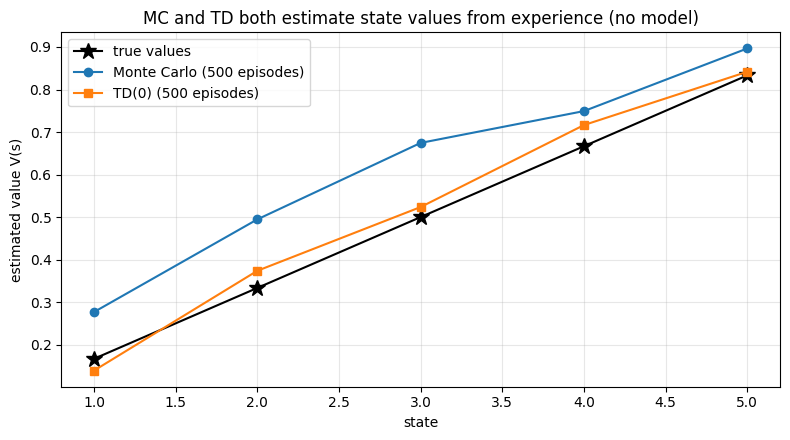

Both approach the true values. TD updates every step (online); MC waits for the episode to end.


In [2]:
# a linear chain: states 0..6, start at 3, terminal at 0 (reward 0) and 6 (reward 1); random walk
N = 7; TERMINALS = {0, 6}
def walk_episode():
    s = 3; traj = []
    while s not in TERMINALS:
        a = np.random.choice([-1, 1]); ns = s + a
        r = 1.0 if ns == 6 else 0.0
        traj.append((s, r, ns)); s = ns
    return traj

true_V = np.array([0, 1/6, 2/6, 3/6, 4/6, 5/6, 0])       # known analytic values (for comparison)

def mc_estimate(episodes, alpha=0.02):
    V = np.zeros(N)
    for _ in range(episodes):
        traj = walk_episode(); G = traj[-1][1]           # return = final reward (gamma=1)
        for (s, r, ns) in traj:
            V[s] += alpha*(G - V[s])                       # nudge toward the actual return
    return V
def td_estimate(episodes, alpha=0.05):
    V = np.zeros(N)
    for _ in range(episodes):
        for (s, r, ns) in walk_episode():
            V[s] += alpha*(r + (V[ns] if ns not in TERMINALS else 0) - V[s])   # TD(0) bootstrap
    return V

fig, ax = plt.subplots(figsize=(8,4.5))
ax.plot(range(1,6), true_V[1:6], "k*-", ms=12, label="true values")
ax.plot(range(1,6), mc_estimate(500)[1:6], "o-", label="Monte Carlo (500 episodes)")
ax.plot(range(1,6), td_estimate(500)[1:6], "s-", label="TD(0) (500 episodes)")
ax.set_title("MC and TD both estimate state values from experience (no model)")
ax.set_xlabel("state"); ax.set_ylabel("estimated value V(s)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("Both approach the true values. TD updates every step (online); MC waits for the episode to end.")


**↳ The TD error** $r + \gamma V(s') - V(s)$ is one of the most important quantities in RL — it's the learning signal in Q-learning below, in actor-critic (NB36), and (as the *advantage*) in PPO (NB37) and RLHF (NB21).


## 2. Q-learning — learning the optimal action-values off-policy

For *control* (finding the best policy, not just evaluating one) we learn **action-values** $Q(s,a)$. **Q-learning** is the celebrated off-policy TD control algorithm:
$$Q(s,a) \leftarrow Q(s,a) + \alpha\Big[r + \gamma\,\max_{a'}Q(s',a') - Q(s,a)\Big].$$
The $\max_{a'}$ means it learns the value of acting *optimally* thereafter, **regardless of how it actually behaved** (that's "off-policy"). To explore, the agent acts **ε-greedy**: mostly greedy (best known action), occasionally random. Given enough exploration, $Q$ converges to $Q^*$ and the greedy policy becomes optimal — *without ever knowing the model.* Let's solve the NB33 gridworld from experience alone.


In [3]:
class GridWorld:
    def __init__(s):
        s.rows, s.cols = 4, 5; s.goal, s.trap = (0,4), (1,4)
        s.walls = {(1,1),(2,1),(1,2)}; s.start = (3,0)
        s.A = ["U","D","L","R"]; s.moves = {"U":(-1,0),"D":(1,0),"L":(0,-1),"R":(0,1)}; s.gamma=0.9
    def reset(s): s.pos = s.start; return s.pos
    def step(s, a):
        dr,dc = s.moves[a]; ns = (s.pos[0]+dr, s.pos[1]+dc)
        if ns[0]<0 or ns[0]>=s.rows or ns[1]<0 or ns[1]>=s.cols or ns in s.walls: ns = s.pos
        s.pos = ns
        if ns==s.goal: return ns, 1.0, True
        if ns==s.trap: return ns, -1.0, True
        return ns, -0.04, False

def q_learning(env, episodes=2000, alpha=0.1, eps=0.1):
    Q = {(r,c):{a:0.0 for a in env.A} for r in range(env.rows) for c in range(env.cols)}
    rewards = []
    for ep in range(episodes):
        s = env.reset(); done=False; total=0
        while not done:
            a = np.random.choice(env.A) if np.random.rand()<eps else max(env.A, key=lambda a:Q[s][a])  # eps-greedy
            ns, r, done = env.step(a); total += r
            target = r + (0 if done else env.gamma*max(Q[ns].values()))
            Q[s][a] += alpha*(target - Q[s][a])           # Q-learning update
            s = ns
        rewards.append(total)
    return Q, rewards

env = GridWorld()
Q, rewards = q_learning(env)
policy = {s: max(Q[s], key=Q[s].get) for s in Q if s not in (env.goal,env.trap) and s not in env.walls}
print(f"trained Q-learning for 2000 episodes. Learned policy at start {env.start}: {policy[env.start]}")


trained Q-learning for 2000 episodes. Learned policy at start (3, 0): R


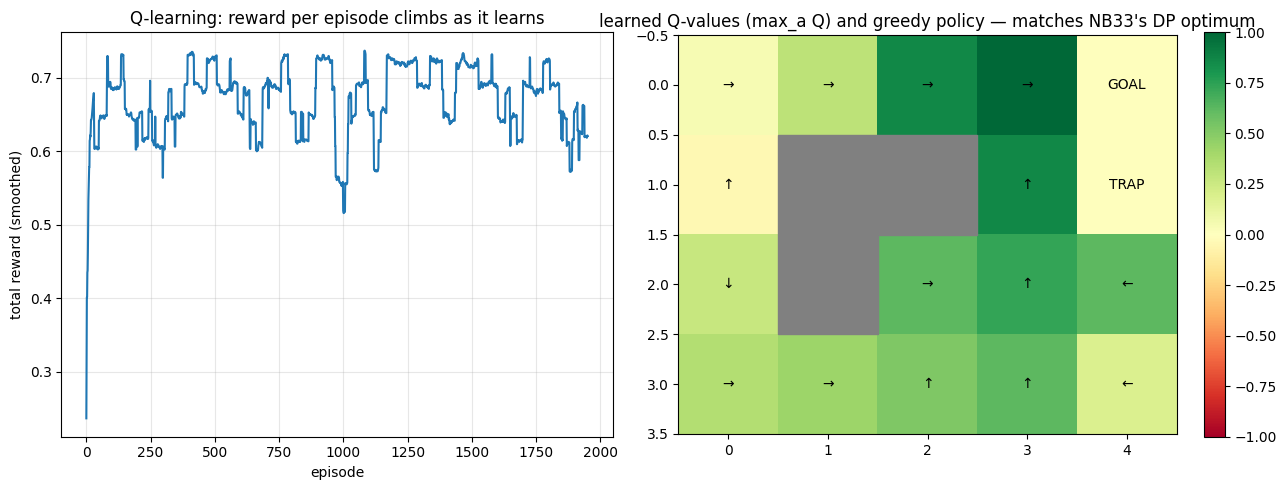

In [4]:
fig, ax = plt.subplots(1,2,figsize=(13,5))
# learning curve
smooth = np.convolve(rewards, np.ones(50)/50, mode="valid")
ax[0].plot(smooth, color="tab:blue"); ax[0].set_title("Q-learning: reward per episode climbs as it learns")
ax[0].set_xlabel("episode"); ax[0].set_ylabel("total reward (smoothed)"); ax[0].grid(alpha=0.3)
# learned value + policy
grid = np.full((env.rows,env.cols), np.nan); arrow={"U":"↑","D":"↓","L":"←","R":"→"}
for s in Q:
    if s in env.walls: continue
    grid[s] = max(Q[s].values())
im = ax[1].imshow(grid, cmap="RdYlGn", vmin=-1, vmax=1)
for s in Q:
    if s in env.walls: continue
    r,c = s
    if s==env.goal: t="GOAL"
    elif s==env.trap: t="TRAP"
    else: t=f"{arrow[policy[s]]}"
    ax[1].text(c,r,t,ha="center",va="center")
for (r,c) in env.walls: ax[1].add_patch(plt.Rectangle((c-.5,r-.5),1,1,color="gray"))
ax[1].set_title("learned Q-values (max_a Q) and greedy policy — matches NB33's DP optimum")
plt.colorbar(im, ax=ax[1], fraction=0.046); plt.tight_layout(); plt.show()


**What to notice.** The learning curve (left) climbs from negative (random flailing) toward the optimal return as Q-learning improves. The learned policy (right) points toward the goal and away from the trap — **the same optimal policy value iteration found in NB33, but learned purely from sampled experience, with no knowledge of the environment's dynamics.** That's the power of model-free RL: give it a reward signal and let it try, and it discovers optimal behavior.


## 3. SARSA vs Q-learning — the cliff-walking classic

**SARSA** is the *on-policy* cousin of Q-learning: instead of $\max_{a'}Q(s',a')$ it uses the value of the action it *actually takes next* (including exploration): $Q(s,a)\leftarrow Q(s,a)+\alpha[r+\gamma Q(s',a')-Q(s,a)]$. This subtle difference has a famous consequence on **cliff-walking** (Sutton & Barto): a grid where the shortest path runs right along a cliff edge (falling in = big penalty).
- **Q-learning** learns the *optimal* path — right along the cliff edge — because its $\max$ ignores its own exploratory missteps.
- **SARSA** learns a *safer* path one row up — because it accounts for the fact that ε-greedy exploration will sometimes push it off the cliff, so it avoids the edge.

Neither is "wrong": Q-learning optimizes the greedy policy; SARSA optimizes the policy it actually follows (exploration included). Let's reproduce it.


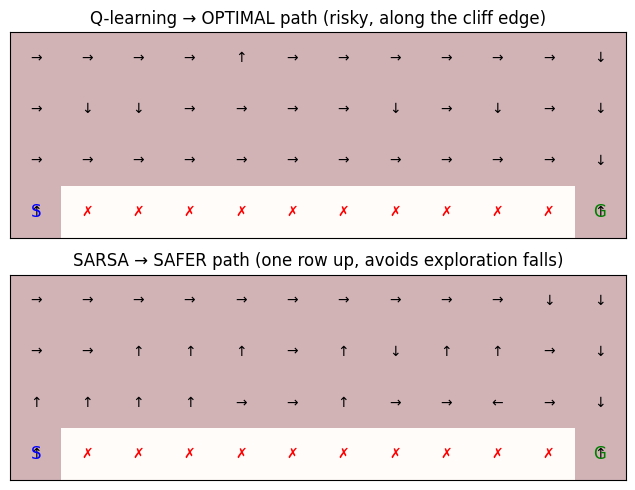

avg reward (last 100 eps): Q-learning -51, SARSA -31


In [5]:
class Cliff:
    def __init__(s): s.rows,s.cols=4,12; s.start=(3,0); s.goal=(3,11); s.A=["U","D","L","R"]; s.gamma=1.0
    def reset(s): s.pos=s.start; return s.pos
    def step(s,a):
        dr,dc={"U":(-1,0),"D":(1,0),"L":(0,-1),"R":(0,1)}[a]
        ns=(min(max(s.pos[0]+dr,0),s.rows-1), min(max(s.pos[1]+dc,0),s.cols-1))
        if ns[0]==3 and 1<=ns[1]<=10:                     # the cliff
            s.pos=s.start; return s.start, -100.0, False
        s.pos=ns; return ns, (0.0 if ns==s.goal else -1.0), ns==s.goal

def train_cliff(algo, episodes=500, alpha=0.5, eps=0.1):
    env=Cliff(); Q={(r,c):{a:0.0 for a in env.A} for r in range(4) for c in range(12)}
    def act(s): return np.random.choice(env.A) if np.random.rand()<eps else max(env.A,key=lambda a:Q[s][a])
    rewards=[]
    for _ in range(episodes):
        s=env.reset(); a=act(s); done=False; tot=0
        while not done:
            ns,r,done=env.step(a); tot+=r; na=act(ns)
            if algo=="q": target=r+(0 if done else env.gamma*max(Q[ns].values()))   # Q-learning: max
            else:          target=r+(0 if done else env.gamma*Q[ns][na])             # SARSA: actual next action
            Q[s][a]+=alpha*(target-Q[s][a]); s,a=ns,na
        rewards.append(tot)
    policy={s:max(Q[s],key=Q[s].get) for s in Q}
    return policy, rewards

pol_q, rew_q = train_cliff("q"); pol_s, rew_s = train_cliff("sarsa")
def draw_path(ax, policy, title):
    arrow={"U":"↑","D":"↓","L":"←","R":"→"}
    grid=np.zeros((4,12))
    for c in range(1,11): grid[3,c]=-1                    # cliff
    ax.imshow(grid, cmap="Reds", alpha=0.3)
    for (r,c),a in policy.items():
        if (r==3 and 1<=c<=10): ax.text(c,r,"✗",ha="center",va="center",color="red"); continue
        ax.text(c,r,arrow[a],ha="center",va="center")
    ax.text(0,3,"S",ha="center",va="center",fontsize=12,color="blue"); ax.text(11,3,"G",ha="center",va="center",fontsize=12,color="green")
    ax.set_title(title); ax.set_xticks([]); ax.set_yticks([])
fig, ax = plt.subplots(2,1,figsize=(11,5))
draw_path(ax[0], pol_q, "Q-learning → OPTIMAL path (risky, along the cliff edge)")
draw_path(ax[1], pol_s, "SARSA → SAFER path (one row up, avoids exploration falls)")
plt.tight_layout(); plt.show()
print(f"avg reward (last 100 eps): Q-learning {np.mean(rew_q[-100:]):.0f}, SARSA {np.mean(rew_s[-100:]):.0f}")


**What to notice.** Q-learning's policy hugs the cliff edge (the shortest, *optimal* path), while SARSA's stays a row higher (a *safer* path). This isn't a bug — it's the **on-policy vs off-policy** distinction made visual: SARSA optimizes the policy it *actually executes* (which sometimes explores off the cliff, so it stays away), while Q-learning optimizes the *greedy* target policy (which never explores, so the edge is fine). During training SARSA often gets higher *actual* reward (it falls off less), even though Q-learning's learned greedy policy is optimal. This on-policy/off-policy distinction directly matters for PPO (on-policy, NB37) and RLHF.

## 4. What you built / learned
- **Monte Carlo vs TD** value estimation — from complete returns vs bootstrapped one-step updates; the **TD error**.
- **Q-learning** (off-policy TD control) — recovered NB33's optimal policy from *experience alone*, no model.
- **ε-greedy** exploration; the explore/exploit tradeoff.
- **SARSA vs Q-learning** — on-policy vs off-policy — reproduced on cliff-walking (safe vs optimal path).

## 5. Exercises
1. **ε schedule.** Decay ε over training; does it converge faster / to a better policy?
2. **α (learning rate).** Sweep the step size; relate to MC (low α, many episodes) vs aggressive TD.
3. **n-step TD.** Implement n-step returns (between MC and TD(0)); find the bias-variance sweet spot.
4. **Expected SARSA.** Use the expectation over next actions instead of the sampled one; compare stability.
5. **Double Q-learning.** Implement it to fix Q-learning's maximization bias (overoptimistic Q).
6. **Eligibility traces / TD(λ).** Add traces to speed credit assignment.

## 6. Interview / residency framing
- *"Model-free vs model-based RL?"* → model-free learns values/policy from sampled experience without knowing $P,R$; model-based learns/uses a model of the environment.
- *"Monte Carlo vs TD?"* → MC uses full-episode returns (unbiased, high variance, needs episode end); TD bootstraps one step (biased, low variance, online). The TD error is the core learning signal.
- *"What is Q-learning?"* → off-policy TD control: $Q\leftarrow Q+\alpha[r+\gamma\max_{a'}Q(s',a')-Q]$; converges to $Q^*$ with sufficient exploration.
- *"On-policy vs off-policy (SARSA vs Q-learning)?"* → SARSA uses the actually-taken next action (learns the behaviour policy, incl. exploration → safer); Q-learning uses the max (learns the greedy optimum → optimal but risky). Cliff-walking shows it.
- *"Explore vs exploit?"* → ε-greedy balances trying new actions vs using the best known; essential for learning the optimal policy.

## 📚 References & papers

This notebook builds on:

- **Reinforcement Learning: An Introduction** — Sutton & Barto (2018, free online). Chapters 5–6 (Monte Carlo, TD, SARSA, Q-learning); the cliff-walking example is Example 6.6.
- **Learning from Delayed Rewards (Q-learning)** — Watkins (1989); Watkins & Dayan (1992), *Machine Learning*.
- **Learning to Predict by the Methods of Temporal Differences** — Sutton (1988), *Machine Learning*.

---
**Next:** *Tier 7 · Notebook 35 — Deep Q-Networks (DQN)*: scaling Q-learning to large/continuous state spaces with a neural network, experience replay, and target networks — the method that first cracked Atari from pixels.
